In [34]:
%load_ext autoreload
%autoreload 2

ModuleNotFoundError: No module named 'imp'

In [3]:
!pip install diffusers transformers accelerate safetensors

In [16]:
!git pull origin main

remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (5/5), done.
remote: Total 6 (delta 1), reused 6 (delta 1), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 3.93 KiB | 804.00 KiB/s, done.
From https://github.com/Felix982/XAI-project
 * branch            main       -> FETCH_HEAD
   bbe695f..b017f5e  main       -> origin/main
Updating bbe695f..b017f5e
Fast-forward
 models/pretrained_diffusion.py                 |  11 +
 notebooks/00_data_and_classifier.ipynb         | 289 ++++++++++++++++++++++++-
 notebooks/01_train_classifier.ipynb            |   0
 notebooks/02_pretrained_diffusion_sanity.ipynb |   0
 4 files changed, 290 insertions(+), 10 deletions(-)
 create mode 100644 models/pretrained_diffusion.py
 create mode 100644 notebooks/01_train_classifier.ipynb
 create mode 100644 notebooks/02_pretrained_diffusion_sanity.ipynb


In [12]:
!git clone https://github.com/Felix982/XAI-project.git

Cloning into 'XAI-project'...
remote: Enumerating objects: 38, done.
remote: Counting objects: 100% (38/38), done.
remote: Compressing objects: 100% (32/32), done.
remote: Total 38 (delta 5), reused 36 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (38/38), 48.59 KiB | 3.47 MiB/s, done.
Resolving deltas: 100% (5/5), done.


In [17]:
%cd XAI-project

/content/XAI-project/XAI-project


In [18]:
import os
import sys
import torch

%cd /content/XAI-project
sys.path.append(os.getcwd())

/content/XAI-project


In [19]:
from models.pretrained_diffusion import (
    load_pretrained_ddpm_pipeline,
    replace_with_ddim_scheduler,
)

pipe = load_pretrained_ddpm_pipeline()
pipe = replace_with_ddim_scheduler(pipe)

device = "cuda" if torch.cuda.is_available() else "cpu"
pipe = pipe.to(device)

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


model_index.json:   0%|          | 0.00/180 [00:00<?, ?B/s]

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/2 [00:00<?, ?it/s]

An error occurred while trying to fetch /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80: Error no file named diffusion_pytorch_model.safetensors found in directory /root/.cache/huggingface/hub/models--google--ddpm-cifar10-32/snapshots/267b167dc01f0e4e61923ea244e8b988f84deb80.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.


In [20]:
print(type(pipe.unet))
print(type(pipe.scheduler))
print(pipe.unet.config)

<class 'diffusers.models.unets.unet_2d.UNet2DModel'>
<class 'diffusers.schedulers.scheduling_ddim.DDIMScheduler'>
FrozenDict({'sample_size': 32, 'in_channels': 3, 'out_channels': 3, 'center_input_sample': False, 'time_embedding_type': 'positional', 'time_embedding_dim': None, 'freq_shift': 1, 'flip_sin_to_cos': False, 'down_block_types': ['DownBlock2D', 'AttnDownBlock2D', 'DownBlock2D', 'DownBlock2D'], 'mid_block_type': 'UNetMidBlock2D', 'up_block_types': ['UpBlock2D', 'UpBlock2D', 'AttnUpBlock2D', 'UpBlock2D'], 'block_out_channels': [128, 256, 256, 256], 'layers_per_block': 2, 'mid_block_scale_factor': 1, 'downsample_padding': 0, 'downsample_type': 'conv', 'upsample_type': 'conv', 'dropout': 0.0, 'act_fn': 'silu', 'attention_head_dim': None, 'norm_num_groups': 32, 'attn_norm_num_groups': None, 'norm_eps': 1e-06, 'resnet_time_scale_shift': 'default', 'add_attention': True, 'class_embed_type': None, 'num_class_embeds': None, 'num_train_timesteps': None, '_use_default_values': ['upsample

In [21]:
images = pipe(num_inference_steps=50, batch_size=8).images
len(images)

  0%|          | 0/50 [00:00<?, ?it/s]

8

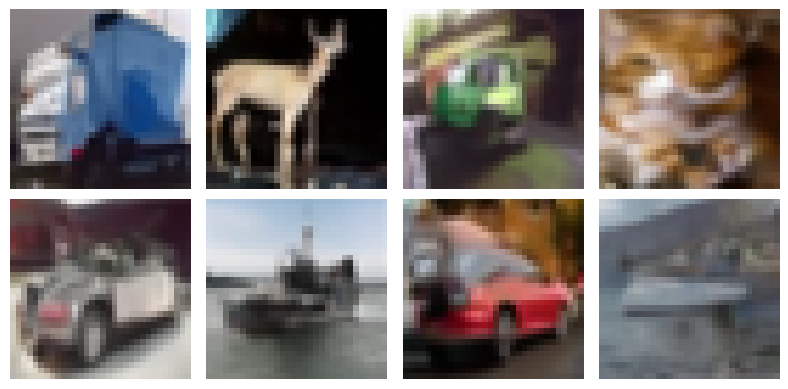

In [22]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(8, 4))
axes = axes.flatten()

for i, img in enumerate(images):
    axes[i].imshow(img)
    axes[i].axis("off")

plt.tight_layout()
plt.show()

In [23]:
import inspect
print(inspect.signature(pipe.unet.forward))

(sample: torch.Tensor, timestep: torch.Tensor | float | int, class_labels: torch.Tensor | None = None, return_dict: bool = True) -> diffusers.models.unets.unet_2d.UNet2DOutput | tuple


# Testing Conditional Unet

In [26]:
!git pull origin main

remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 4 (delta 3), reused 4 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (4/4), 590 bytes | 590.00 KiB/s, done.
From https://github.com/Felix982/XAI-project
 * branch            main       -> FETCH_HEAD
   310f4b4..94e85f8  main       -> origin/main
Updating 310f4b4..94e85f8
Fast-forward
 models/conditional_unet.py | 27 ++++++++++++++++++++++++---
 1 file changed, 24 insertions(+), 3 deletions(-)


In [30]:
import importlib
import models.conditional_unet
importlib.reload(models.conditional_unet)

from models.conditional_unet import (
    build_class_conditional_unet_from_pretrained,
    sanity_check_conditional_unet,
)

device = "cuda" if torch.cuda.is_available() else "cpu"

cond_unet, info = build_class_conditional_unet_from_pretrained(
    repo_id="google/ddpm-cifar10-32",
    num_classes=2,
    device=device,
)

print("Missing keys:")
for k in info["missing_keys"]:
    print("  ", k)



shape = sanity_check_conditional_unet(
    cond_unet,
    batch_size=4,
    image_size=32,
    num_train_timesteps=1000,
    device=device,
)
print(shape)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:206: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


Missing keys:
   class_embedding.weight
torch.Size([4, 3, 32, 32])


In [31]:

import importlib
import data.medmnist
importlib.reload(data.medmnist)
from data.medmnist import get_dataloader

loader = data.medmnist.get_dataloader(
    split="train",
    batch_size=8,
    image_size=32,
    num_channels=3,
    root="./data",
    num_workers=2,
)

batch = next(iter(loader))
images = batch["image"]
labels = batch["label"]

print(images.shape)   # should be [8, 3, 32, 32]
print(labels.shape)   # should be [8]
print(images.min().item(), images.max().item())

torch.Size([8, 3, 32, 32])
torch.Size([8])
-1.0 0.9137254953384399
